# Imports

In [55]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
import matplotlib.pyplot as plt

# Key Methods

In [56]:
def apply_gridsynth_to_circuit(circuit, qubit, gridsynth_string):
    """
    Apply a gridsynth rotation sequence to an existing circuit.

    Args:
    circuit: Existing QuantumCircuit
    qubit_index: Which qubit to apply gates to
    gridsynth_string: Output string from gridsynth

    Returns:
    Updated QuantumCircuit with gates from gridsynth_string applied to the specified qubit.
    """
    # Apply gates from right to left
    for gate in reversed(gridsynth_string.upper()):
        if gate == 'T':
            circuit.t(qubit)
        elif gate == 'S':
            circuit.s(qubit)
        elif gate == 'H':
            circuit.h(qubit)
        elif gate == 'X':
            circuit.h(qubit)
            circuit.s(qubit)
            circuit.s(qubit)
            circuit.h(qubit)
            # circuit.x(qubit)
            # pass
        elif gate == 'W':
            circuit.global_phase += np.pi/4
            # pass
    return circuit  

In [57]:
import subprocess

def run_gridsynth(angle, random_seed=40) -> str:
    """
    Run gridsynth and return the output string.
    
    Args:
        angle: Angle expression as string (e.g., "pi/4", "-2*pi/7")
    
    Returns:
        Gridsynth output string
    """
    result = subprocess.run(
        [r"C:\cabal\bin\gridsynth.exe", angle, f"-r {random_seed}"],
        capture_output=True,
        text=True
    )
    return result.stdout.strip()

def run_gridsynth(angle, options=["--phase"]) -> str:
    """
    Run gridsynth and return the output string.
    
    Args:
        angle: Angle expression as string (e.g., "pi/4", "-2*pi/7")
        options: List of option strings (e.g., ["-d", "100"])
    
    Returns:
        Gridsynth output string
    """
    cmd = [r"C:\cabal\bin\gridsynth.exe"]
    if options:
        cmd.extend(options)
    cmd.append(angle)
    
    result = subprocess.run(cmd, capture_output=True, text=True)
    return result.stdout.strip()


In [58]:
def distance(u, v):
    """Calculate the distance (as defined in challenge description) between two unitary operators u and v.
    
    Args:
    u: Unitary operator (as a qiskit Operator object)
    v: Unitary operator (as a qiskit Operator object)
    
    Returns:
    Distance between u and v.
    """
    product = v.compose(u.adjoint())
    overlap = np.abs(product.to_matrix().trace()) / 2.0
    # overlap = min(overlap, 1.0) 
    return np.sqrt(1.0 - overlap)


# Running Experiment for various n values

In [59]:
distances = []
n_list = []
for n in range(34):
    rotation_angle = np.pi / 2**n
    qc = QuantumCircuit(1)
    qc.rz(rotation_angle, 0)
    v = Operator(qc)
    u = Operator(apply_gridsynth_to_circuit(QuantumCircuit(1), 0, run_gridsynth(f"pi/{2**n}")))
    distances.append(distance(u, v))
    n_list.append(n)


C:\Users\marlo_2lbtn5r\AppData\Local\Temp\ipykernel_34472\587618970.py:14: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(1.0 - overlap)


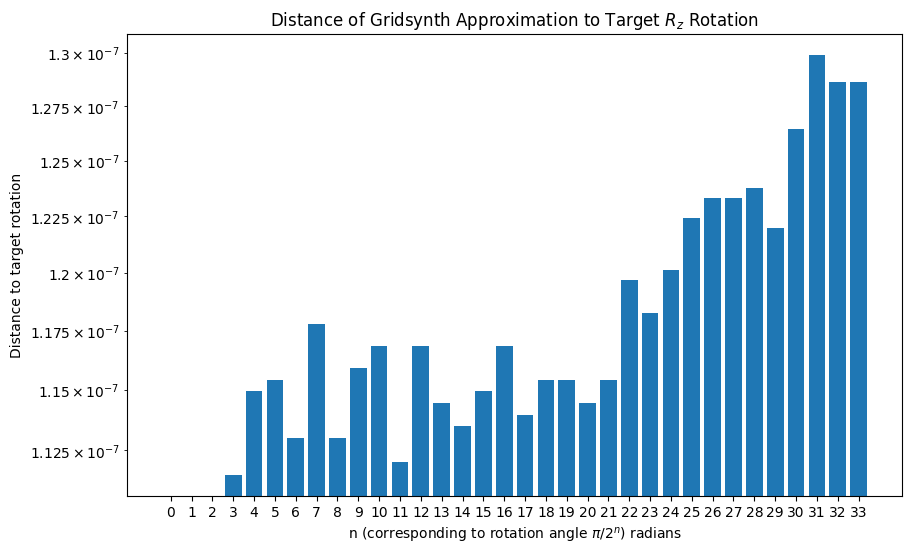

In [60]:
plt.figure(figsize=(10, 6))
plt.bar(n_list, distances)
plt.xticks(n_list)
plt.xlabel("n (corresponding to rotation angle $\\pi/2^n$) radians")
plt.ylabel("Distance to target rotation")
plt.title("Distance of Gridsynth Approximation to Target $R_z$ Rotation")
plt.yscale("log")
plt.savefig("Figures/gridsynth_distance_plot.png", dpi=300, bbox_inches='tight')
